Normal samples: 1916
Attack samples: 70

Model trained on NORMAL data only (with MinMax scaling).


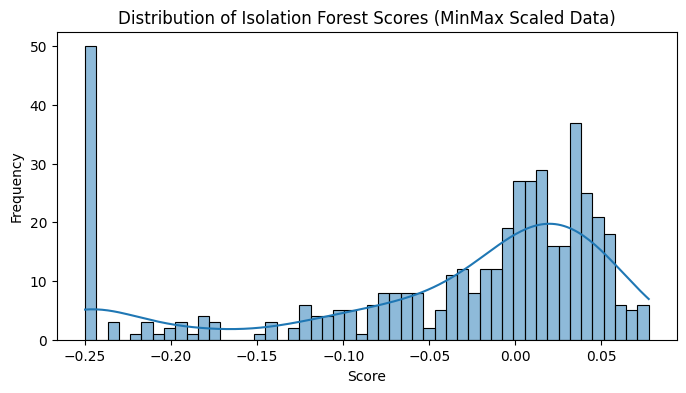


Mean (μ): -0.0003875214421810094
Std (σ): 0.04684014650873302
Chosen k: 2.4
Threshold (μ - kσ): -0.11280387306314026

Confusion Matrix (μ - kσ Threshold):
[[368  16]
 [  0  70]]

Classification Report (μ - kσ Threshold):
              precision    recall  f1-score   support

      Normal       1.00      0.96      0.98       384
      Attack       0.81      1.00      0.90        70

    accuracy                           0.96       454
   macro avg       0.91      0.98      0.94       454
weighted avg       0.97      0.96      0.97       454



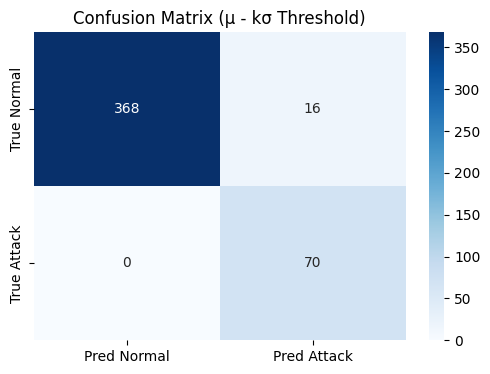

In [18]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest


# =========================================================
# 1) Load Labeled Dataset
# =========================================================
df = pd.read_csv("merged_123_20.csv")

# Labels: Normal = -1, Attack = 1
df_normal = df[df["label"] == -1].copy()
df_attack = df[df["label"] == 1].copy()

print("Normal samples:", len(df_normal))
print("Attack samples:", len(df_attack))

# =========================================================
# 2) Split NORMAL data into train and test (80% train, 20% test)
# =========================================================
df_train_normal, df_test_normal = train_test_split(df_normal, test_size=0.2, random_state=42)

# =========================================================
# 3) Prepare training data (features only)
# =========================================================
X_train = df_train_normal.drop(columns=["label"])
X_test = pd.concat([df_test_normal, df_attack], ignore_index=True).drop(columns=["label"])
y_true = pd.concat([df_test_normal, df_attack], ignore_index=True)["label"]

# =========================================================
# 4) Apply MinMaxScaler
# =========================================================
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================================================
# 5) Train Isolation Forest on scaled NORMAL training data
# =========================================================
model =model = IsolationForest(
    n_estimators=200,
    max_samples="auto",
    contamination="auto",
    max_features=1.0,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train_scaled)
print("\nModel trained on NORMAL data only (with MinMax scaling).")

# =========================================================
# 6) Get anomaly scores on scaled test data
# =========================================================
scores = model.decision_function(X_test_scaled)

# =========================================================
# 7) Plot distribution of scores
# =========================================================
plt.figure(figsize=(8,4))
sns.histplot(scores, bins=50, kde=True)
plt.title("Distribution of Isolation Forest Scores (MinMax Scaled Data)")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

# =========================================================
# 8) Compute μ − kσ threshold using ONLY normal test scores
# =========================================================
scores_normal = model.decision_function(X_train_scaled)

mu = np.mean(scores_normal)
sigma = np.std(scores_normal)

k = 2.4

threshold = mu - k * sigma

print("\nMean (μ):", mu)
print("Std (σ):", sigma)
print("Chosen k:", k)
print("Threshold (μ - kσ):", threshold)

# =========================================================
# 9) Predict using μ − kσ threshold
# =========================================================
y_pred = np.where(scores < threshold, 1, -1)  # 1 = Attack, -1 = Normal

# =========================================================
# 10) Evaluate performance
# =========================================================
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix (μ - kσ Threshold):")
print(cm)

print("\nClassification Report (μ - kσ Threshold):")
print(classification_report(y_true, y_pred, target_names=["Normal", "Attack"]))

# =========================================================
# 11) Plot Confusion Matrix
# =========================================================
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d",
            xticklabels=["Pred Normal", "Pred Attack"],
            yticklabels=["True Normal", "True Attack"])
plt.title("Confusion Matrix (μ - kσ Threshold)")
plt.show()
